# **Unsupervised Learning Project: AllLife Bank Customer Segmentation**

# **Marks: 30**

Welcome to the project on Unsupervised Learning. We will be using **Credit Card Customer Data** for this project.

--------------------------------
## **Context**
-------------------------------

**AllLife Bank wants to focus on its credit card customer base** in the next financial year. They have been advised by their marketing research team, that the penetration in the market can be improved. Based on this input, the marketing team proposes to run personalized campaigns to target new customers as well as upsell to existing customers.

Another insight from the market research was that the customers perceive the support services of the bank poorly. Based on this, the operations team wants to upgrade the service delivery model, to ensure that customers' queries are resolved faster. The head of marketing and the head of delivery, both decide to reach out to the Data Science team for help.


----------------------------
## **Objective**
-----------------------------

**Identify different segments in the existing customer base**, taking into account their spending patterns as well as past interactions with the bank.

--------------------------
## **About the data**
--------------------------

Data is available on customers of the bank with their credit limit, the total number of credit cards the customer has, and different channels through which the customer has contacted the bank for any queries. These different channels include visiting the bank, online, and through a call center.

- **Sl_no** - Customer Serial Number
- **Customer Key** - Customer identification
- **Avg_Credit_Limit**	- Average credit limit (currency is not specified, you can make an assumption around this)
- **Total_Credit_Cards** - Total number of credit cards
- **Total_visits_bank**	- Total bank visits
- **Total_visits_online** - Total online visits
- **Total_calls_made** - Total calls made

## **Importing libraries and overview of the dataset**

**Note:** Please make sure you have installed the sklearn_extra library before running the below cell. If you have not installed the library, please run the below code to install the library:

In [ ]:
!pip install scikit-learn-extra

**Note**: After running this commands, you’ll be prompted to restart your notebook/runtime. Please go ahead and do that. Once restarted, simply proceed to the next step of your workflow

In [ ]:
!pip install numpy==1.26.0

## **Importing the necessary libraries and overview of the dataset**

In [ ]:
#Import libraries for data manipulation
import numpy as np
import pandas as pd

#Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#To scale the data using Z-score
from sklearn.preprocessing import StandardScaler

#Import libraries for PCA
from sklearn.decomposition import PCA

# To compute distances
from scipy.spatial.distance import cdist, pdist

# To perform K-Means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# To import K-Medoids
from sklearn_extra.cluster import KMedoids

# To import DBSCAN and Gaussian Mixture
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

# To perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

import warnings
warnings.filterwarnings("ignore")


### **Loading the data**

In [ ]:
# Read the data
df=pd.read_excel('/content/Credit Card Customer Data.xlsx')

In [ ]:
# Returns the first 5 rows of the data
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [ ]:
#Shape of the dataset
df.shape

(660, 7)

In [ ]:
# Viewing the random 10 rows of the dataset
df.sample(10,random_state=1)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
547,548,38125,26000,4,5,2,4
353,354,94437,9000,5,4,1,3
499,500,65825,68000,6,4,2,2
173,174,38410,9000,2,1,5,8
241,242,81878,10000,4,5,1,3
341,342,70779,18000,4,3,2,0
647,648,79953,183000,9,0,9,2
218,219,28208,19000,3,1,5,7
120,121,16577,10000,4,2,4,6
134,135,31256,13000,4,1,5,7


In [ ]:
# Concise summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [ ]:
# Returns the datatype of each column in the dataset
df.dtypes

,0
Sl_No,int64
Customer Key,int64
Avg_Credit_Limit,int64
Total_Credit_Cards,int64
Total_visits_bank,int64
Total_visits_online,int64
Total_calls_made,int64


In [ ]:
# Check for missing data in the dataset
df.isnull().sum()

,0
Sl_No,0
Customer Key,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0


In [ ]:
# Another way to check for missing data in the dataset
df.isna().any()

,0
Sl_No,False
Customer Key,False
Avg_Credit_Limit,False
Total_Credit_Cards,False
Total_visits_bank,False
Total_visits_online,False
Total_calls_made,False


In [ ]:
#Checking for duplicate data in the dataset
df.duplicated().sum()


0

### **Data Overview**

**Observations**
* The dataset contains 660 customer records with 7 columns describing the spending patterns of the customer.
* The spending patterns are represented by average credit limit,total credit cards, total bank visits, total online visit and total calls made.
* The Customer Key is the unique customer identification number, the primary key of the dataset
* All the columns in the dataset are numeric datatype.

**Sanity checks**
* All the 660 records of customer are non-null values which means there is no missing values in the dataset.
* There is no duplicate records in the dataset.




## **Data Preprocessing and Exploratory Data Analysis**

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.
- Check and drop the duplicate customer keys
- Drop the variables that are not required for the analysis
- Check duplicate rows and remove them.


**Questions:**

1. How does the distribution and outliers look for each variable in the data?
2. How are the variables correlated with each other?

In [ ]:
#Check uniqueness of each data
df.nunique()

,0
Sl_No,660
Customer Key,655
Avg_Credit_Limit,110
Total_Credit_Cards,10
Total_visits_bank,6
Total_visits_online,16
Total_calls_made,11


**Observation**
* The Sl_No column of the dataset is the index column of the dataset.
* Since it is not the primary key of the dataset and will not provide any insights, it is safer to exclude it from further exploration
* The Customer Key column has 5 duplicate records hence further investigation of the column will be carried out in the next **step**

In [ ]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [ ]:
# Dropping the Sl_No column
df.drop('Sl_No',axis=1,inplace=True)

# Check the Sl_No is dropped in the dataset
df.head()

,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,87073,100000,2,1,1,0
1,38414,50000,3,0,10,9
2,17341,50000,7,1,3,4
3,40496,30000,5,1,1,4
4,47437,100000,6,0,12,3


**Standardize the column names**


In [ ]:
# Function to convert all the column names to standard format
def feature_name_standardize(data:pd.DataFrame):
  data_=data.copy();
  data_.columns=[i.replace(" ","_").lower() for i in data_.columns]
  return data_

In [ ]:
# Convert all the columns in the dataset to standard format
df=feature_name_standardize(df)
df.head()

,customer_key,avg_credit_limit,total_credit_cards,total_visits_bank,total_visits_online,total_calls_made
0,87073,100000,2,1,1,0
1,38414,50000,3,0,10,9
2,17341,50000,7,1,3,4
3,40496,30000,5,1,1,4
4,47437,100000,6,0,12,3


In [ ]:
# #Creating a copy of the data
# newData = df.copy()
# newData.info()

In [ ]:
#Creating a copy of the data
newData = df.copy()
newData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   customer_key         660 non-null    int64
 1   avg_credit_limit     660 non-null    int64
 2   total_credit_cards   660 non-null    int64
 3   total_visits_bank    660 non-null    int64
 4   total_visits_online  660 non-null    int64
 5   total_calls_made     660 non-null    int64
dtypes: int64(6)
memory usage: 31.1 KB


#### **Analysing the records for duplicate customer_key** ####

In [ ]:
df['customer_key'].duplicated().sum()

df[df['customer_key'].isin(df[df['customer_key'].duplicated()]['customer_key'].tolist())].sort_values(by=['customer_key'])

,customer_key,avg_credit_limit,total_credit_cards,total_visits_bank,total_visits_online,total_calls_made
48,37252,6000,4,0,2,8
432,37252,59000,6,2,1,2
4,47437,100000,6,0,12,3
332,47437,17000,7,3,1,0
411,50706,44000,4,5,0,2
541,50706,60000,7,5,2,2
391,96929,13000,4,5,0,0
398,96929,67000,6,2,2,2
104,97935,17000,2,1,2,10
632,97935,187000,7,1,7,0


**Observation**
* The records for same customer_key looks very different. For eg: The total_credit_cards record for customer_key: 37252 is 4 in one record and 6 in another record. And current version indicator is missing the dataset, it is not clear whether there is a mistake in the customer_key assigment or which one is the updated record.
* Since it is only 5 records, it is better to use it as an two different customers and analyze the records after the segmentation. Hence 5 duplicate customer_key record is not deleted from the dataset

In [ ]:
#Dropping the customer_key from the dataset
df.drop('customer_key',axis=1,inplace=True)

#print the dataset
df.head()

,avg_credit_limit,total_credit_cards,total_visits_bank,total_visits_online,total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3


**Observation**
* Due to the high cardinaltiy of customer_key, it will not give any insights for our exploration. So it is safe to drop it now.

#### **Check the summary Statistics**

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
avg_credit_limit,660.0,34574.242424,37625.487804,3000.0,10000.0,18000.0,48000.0,200000.0
total_credit_cards,660.0,4.706061,2.167835,1.0,3.0,5.0,6.0,10.0
total_visits_bank,660.0,2.403030,1.631813,0.0,1.0,2.0,4.0,5.0
total_visits_online,660.0,2.606061,2.935724,0.0,1.0,2.0,4.0,15.0
total_calls_made,660.0,3.583333,2.865317,0.0,1.0,3.0,5.0,10.0


**Observations**
* The total_credit_cards hold by customers varies from 1 to 10. The 50% percentile of number of credit cards hold by a customers is 5.
* There are some customers who have not visited their bank. There are some customers who have not accessed the digital platform of the bank
* In general, online access of the bank is more preferred by the customers than going in person.
* The maximum time the customers has called the banks is 10 and some customers have never called the bank.
* The average credit limit of a customers ranges between 3000 and 20000. The currency is not mentioned and allowed to assume. Hence the credit limit will be in terms of $.

## **Univariate Analysis** ##


In [ ]:
# Function to plot a histogram and boxplot in the same page
def plt_hist_boxplot(df, feature, figsize=(12,7),kde=False,bins=None):
  """"
  Boxplot and Histogram Combined
  df : dataframe
  feature : column name
  figsize : size of the figure (default = (12,7))
  kde : Kernel Density Estimate (default = False)
  bins : bins for histogram (default = None)
  """
  f2,(ax2_box2,ax2_hist2)=plt.subplots(
      nrows=2, # No of rows of the subplot grid = 2
      sharex=True, # X-axis will be shared among all subplots
      gridspec_kw={"height_ratios":(0.25,0.75)},
      figsize=figsize
  )

  # Creating the 2 subplots - histogram and boxplot

  # Create the histogram for the dataset
  sns.histplot(
      data=df,
      x=feature,
      kde=kde,
      bins=bins,
      ax=ax2_hist2,

  ) if bins else sns.histplot(
      data=df,
      x=feature,
      kde=kde,
      ax=ax2_hist2,

  )
  # Add mean to the histogram plot
  ax2_hist2.axvline(
    df[feature].mean(),
    color="red",
    linestyle='--')

  # Add median to the histogram plot
  ax2_hist2.axvline(
      df[feature].median(),
      color="black",
      linestyle='-')

  # Create the boxplot and star will indicate the mean value of the dataset
  sns.boxplot(
      data=df,
      x=feature,
      ax=ax2_box2,
      showmeans=True,
      color="gold")

In [ ]:
#Selecting the columns for the analysis
cols = df.select_dtypes(include=np.number).columns.tolist()

#cols.remove('customer_key')
# for i in cols:
#   plt_hist_boxplot(df,i,bins=50,kde=True,figsize=(5,5))

In [ ]:
# # Dropping the Customer Key column as it presence is not much needed for exploration
# df.drop('customer_key',axis=1,inplace=True)

**Distribution of average card limit**

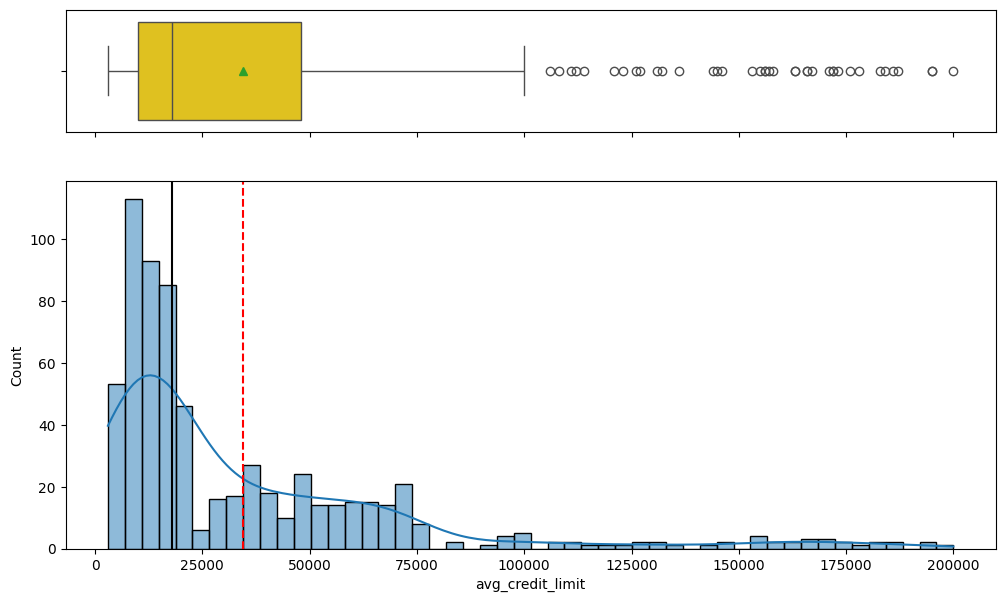

In [ ]:
# Average credit Limit
plt_hist_boxplot(df,'avg_credit_limit',bins=50,kde=True)

**Observation**
* The distribution reveals siginificant right skew in avg_credit_limit. This indicates bank has a large base of low to moderate customers.
* The avg_credit_limit has notable high end outliers. The dataset contains customer with average credit limit > $100000. Eventhough it is a small base, the credit limit is too high to ignore.


**Distribution of total credit cards held by the Customers**

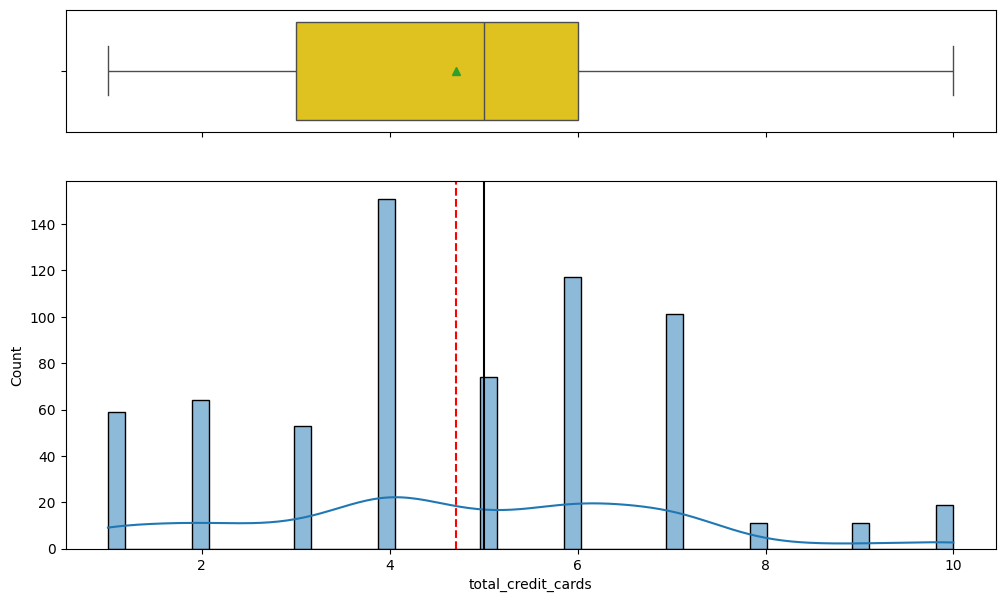

In [ ]:
# Total_credit_cards
plt_hist_boxplot(df,'total_credit_cards',bins=50,kde=True)

**Observation**
* The distribution shows that total_credit_cards is clustered tightly between 2 and 6.
* It also suggest half of the customer base hold atleast 5 credit cards with All life Bank.

**Distribution of total visits to the bank by the customers**

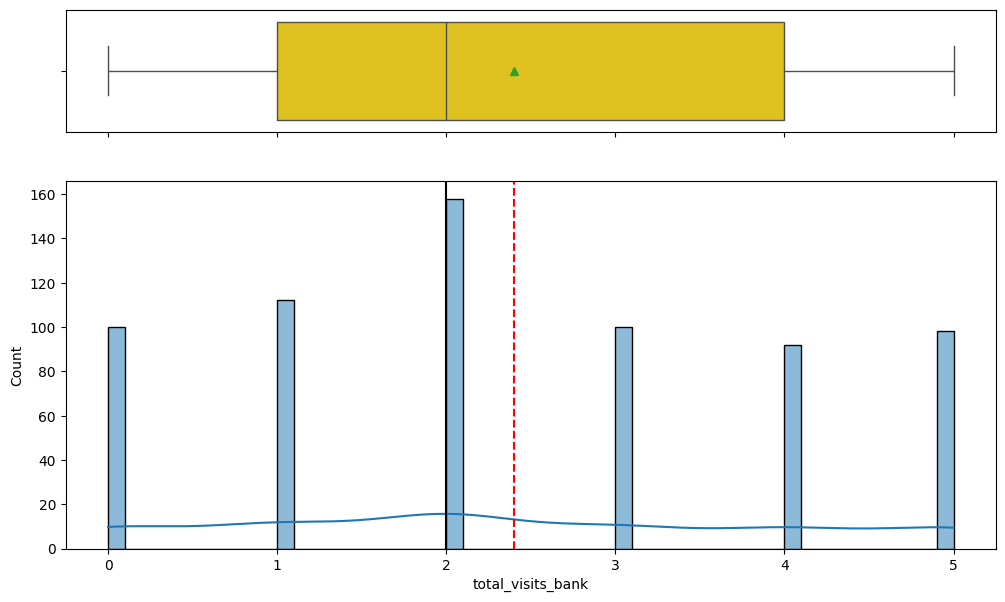

In [ ]:
# Total Visits to the bank
plt_hist_boxplot(df,'total_visits_bank',bins=50,kde=True)

**Observation**
* The ditribution shows that customers visit to the bank is very infrequent.
* The median value of the totat_visits_bank is 2.

**Distribution of total online visits through bank web page by the customer**

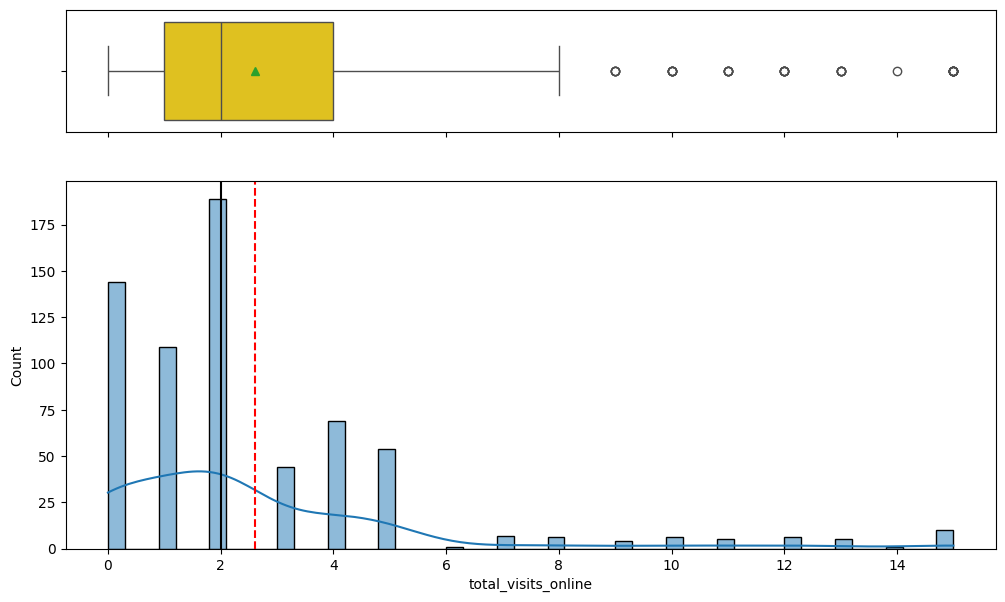

In [ ]:
# Total online visits
plt_hist_boxplot(df,'total_visits_online',bins=50,kde=True)

**Observation**
* The distribution shows that customers online access through bank's website is right skewed. Which means most of customers are infrequent in accessing the account online.
* The median value of the totat_visits_online is 2. This proves that half the bank's base has accessed the bank only 2 times.

**Distribution of total calls made by the customer to the bank**

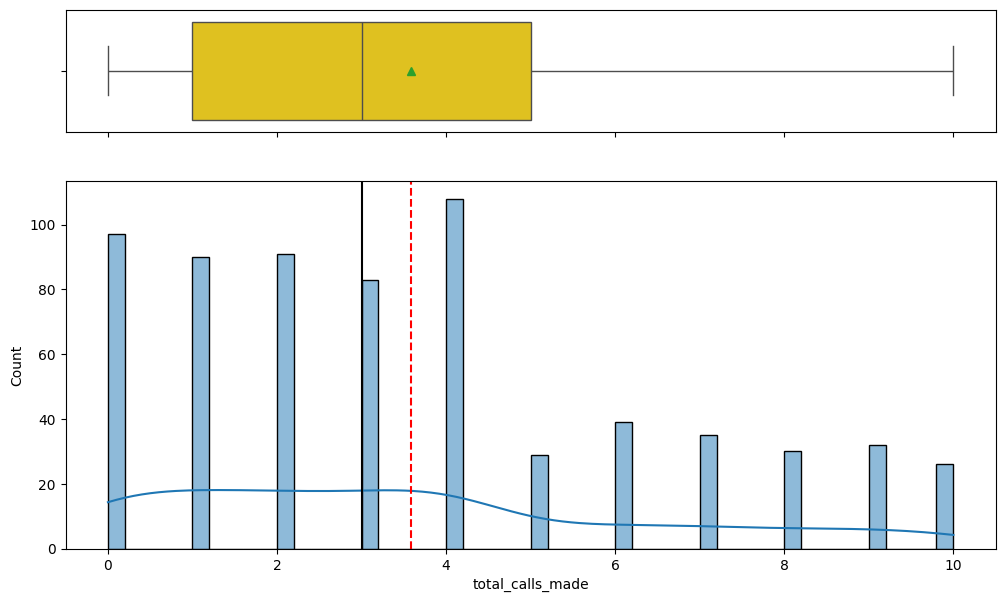

In [ ]:
# Total calls made
plt_hist_boxplot(df,'total_calls_made',bins=50,kde=True)

**Observation**
* The distribution exhibit a wide range with a heavy tail. This suggest a sub group of customers is reliant on the call center support .
* The median value of the column 'total_calls_made' is 3.

In [ ]:
#Function to the labeled barplots
def labeled_barplot(df,feature,perc=False,n=None):
  """
  Barplot with percentage at the top
  df:dataframe
  feature:column name
  perc:whether to display percentage instead of count (default is False)
  n:displays the top n category levels (default is None, i.e., display all levels)

  """
  total=len(df[feature])
  count=df[feature].nunique()
  if n is None:
   plt.figure(figsize=(count+2,6))
  else:
    plt.figure(figsize=(n+2,6))
  plt.xticks(rotation=90,fontsize=10)
  ax=sns.countplot(
      data=df,
      x=feature,
      hue=feature,
      palette="Paired",
      order=df[feature].value_counts().index[:n].sort_values(),
  )
  for p in ax.patches:
    if perc==True:
      label="{:.1f}%".format(100*p.get_height()/total) # Percentage of each class of the category
    else:
      label=p.get_height() #Count of each level of the category
    x=p.get_x()+p.get_width()/2
    y=p.get_height()
    ax.annotate(
      label,
      (x,y),
      ha="center",
      va="center",
      size=7,
      xytext=(0,5),
      textcoords="offset points",) # Annotate the percentage
  plt.tight_layout()
  plt.show()

In [ ]:
# Creating a credit card limit bin out of the available dataset
df['credit_card_limit']=pd.cut(
    df['avg_credit_limit'],
    bins=[3000,10000,18000,48000,200000],
    labels=['Very Low','Low','Mid','High'],
    include_lowest=True
)

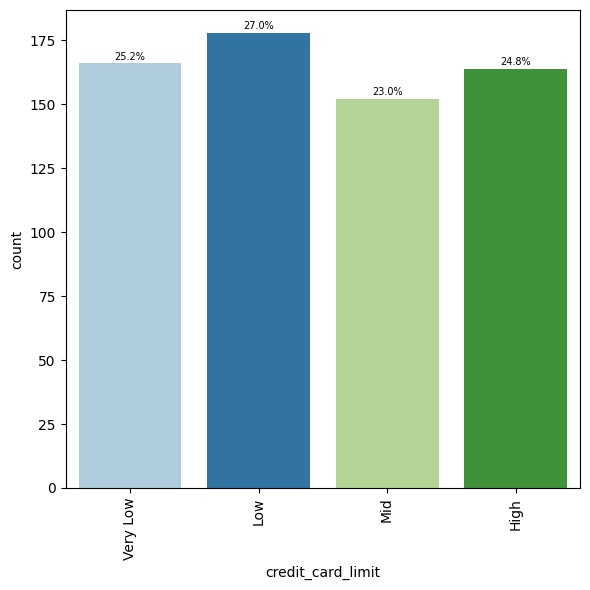

In [ ]:
labeled_barplot(df,'credit_card_limit',perc=True)

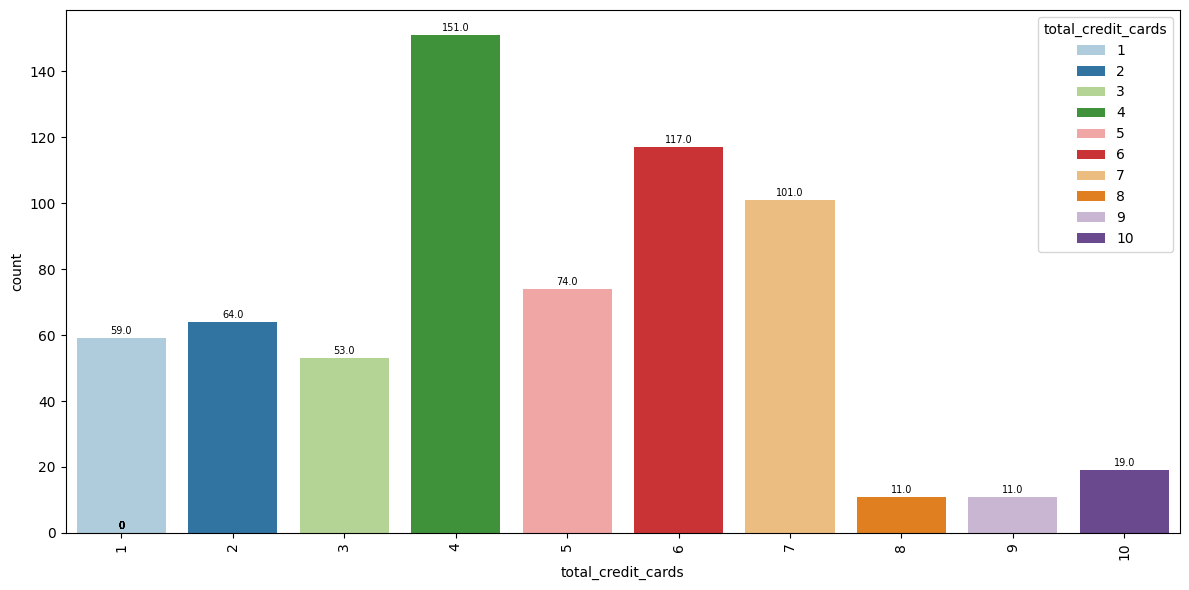

In [ ]:
labeled_barplot(df,'total_credit_cards')

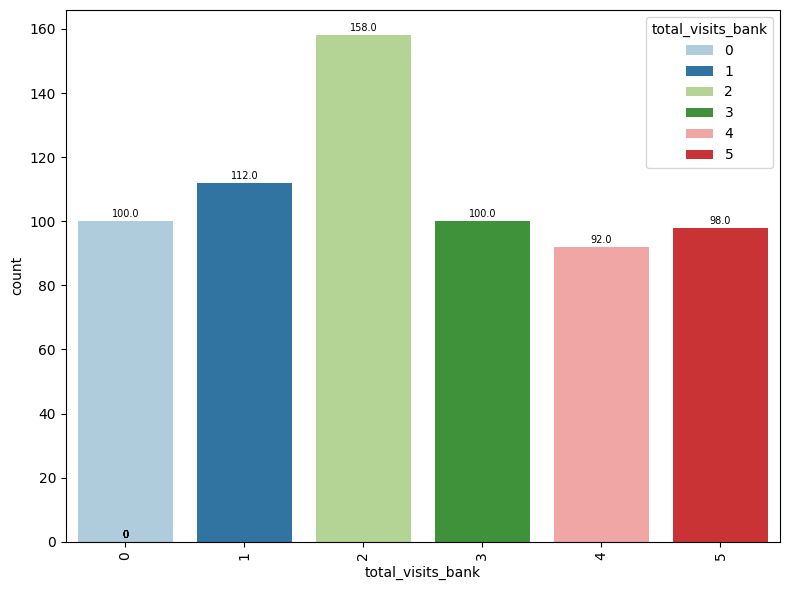

In [ ]:
labeled_barplot(df,'total_visits_bank')

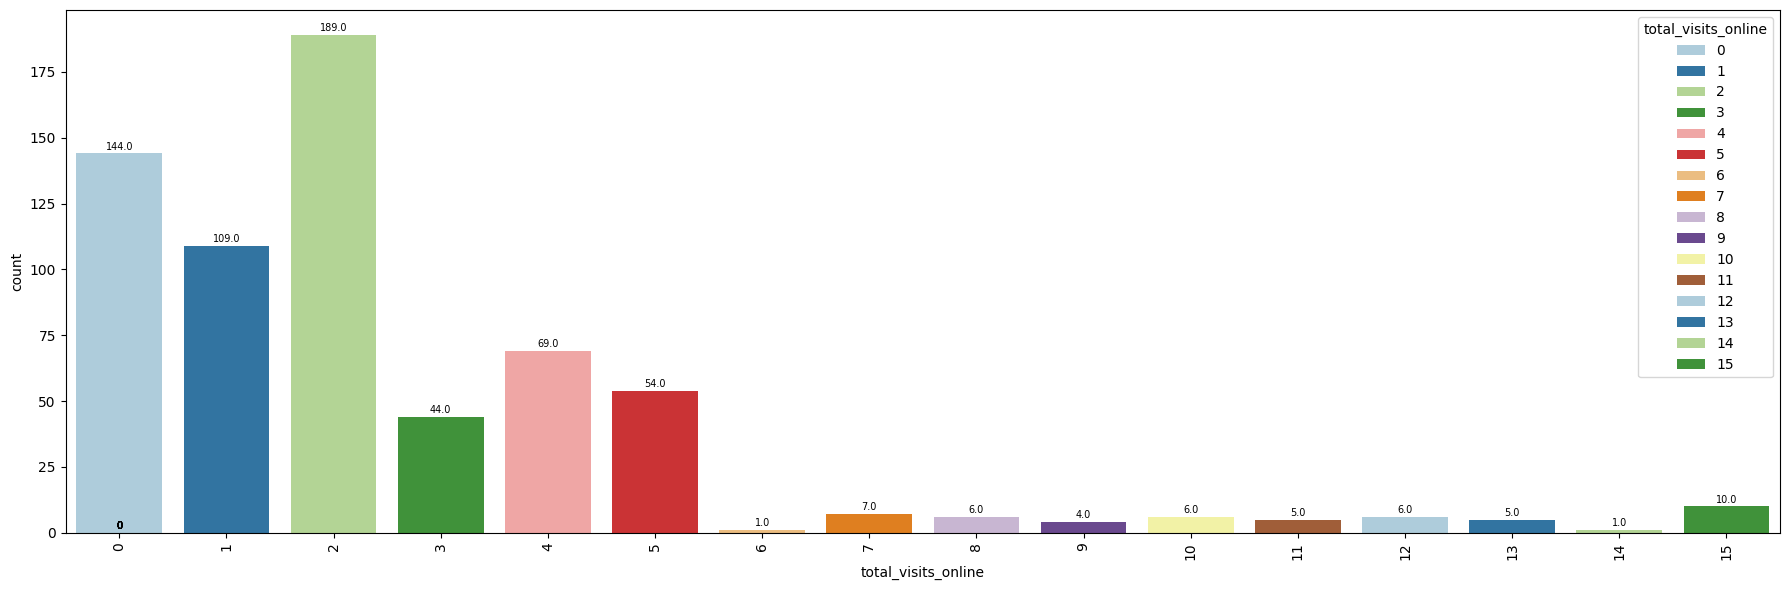

In [ ]:
labeled_barplot(df,'total_visits_online')

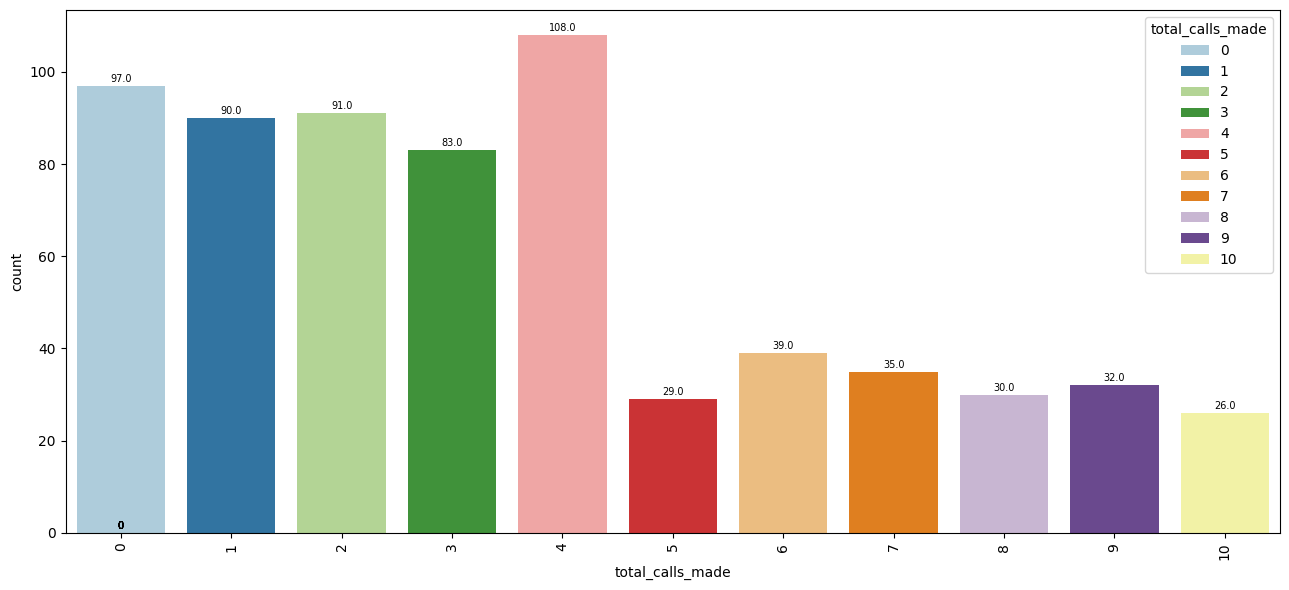

In [ ]:
labeled_barplot(df,'total_calls_made')

###**Correlation Matrix Among Different Variables**


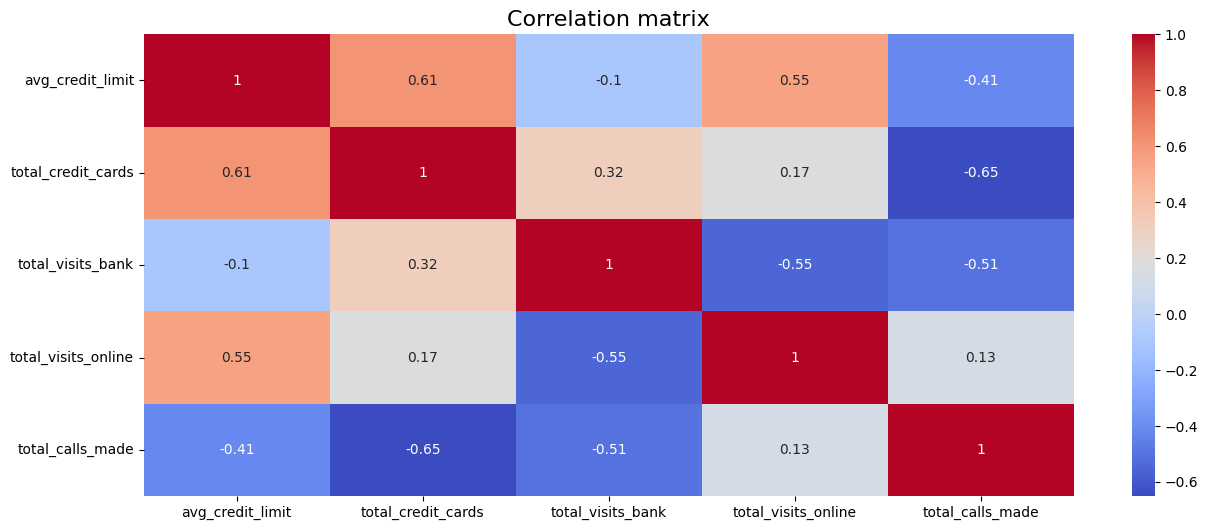

In [ ]:
# Heatmap showing the correlation matrix
plt.figure(figsize=(15,6))
sns.heatmap(df[cols].corr(),annot=True,cmap='coolwarm')
plt.title('Correlation matrix',fontsize=16)
plt.show()

**Observation**
* The avg_credit_limit and total_credit_cards shows a strong positive correlation(r=0.61). This confirms that the average credit limit is higher for customers with higher credit cards.
* The total_visits_online and avg_credit_limit shows moderate positive correlation(r=0.55). This suggest that the high value customers prefer online channels
* The total_calls_made and total_credit_cards has a strong negative correlation(r=-0.65) suggesting the high value customers call less.
* The total_visits_bank has a strong negative correlation with total_visits_online (r=-0.55) and total_calls_made(r=-0.51) respectively. This confirms that the customers who visit banks don't use the digital channels available.
* The avg_credit_cards and the total_call_made shows a strong negative correlation(r=-0.41) suggesting the wealthier customers are self sufficient.


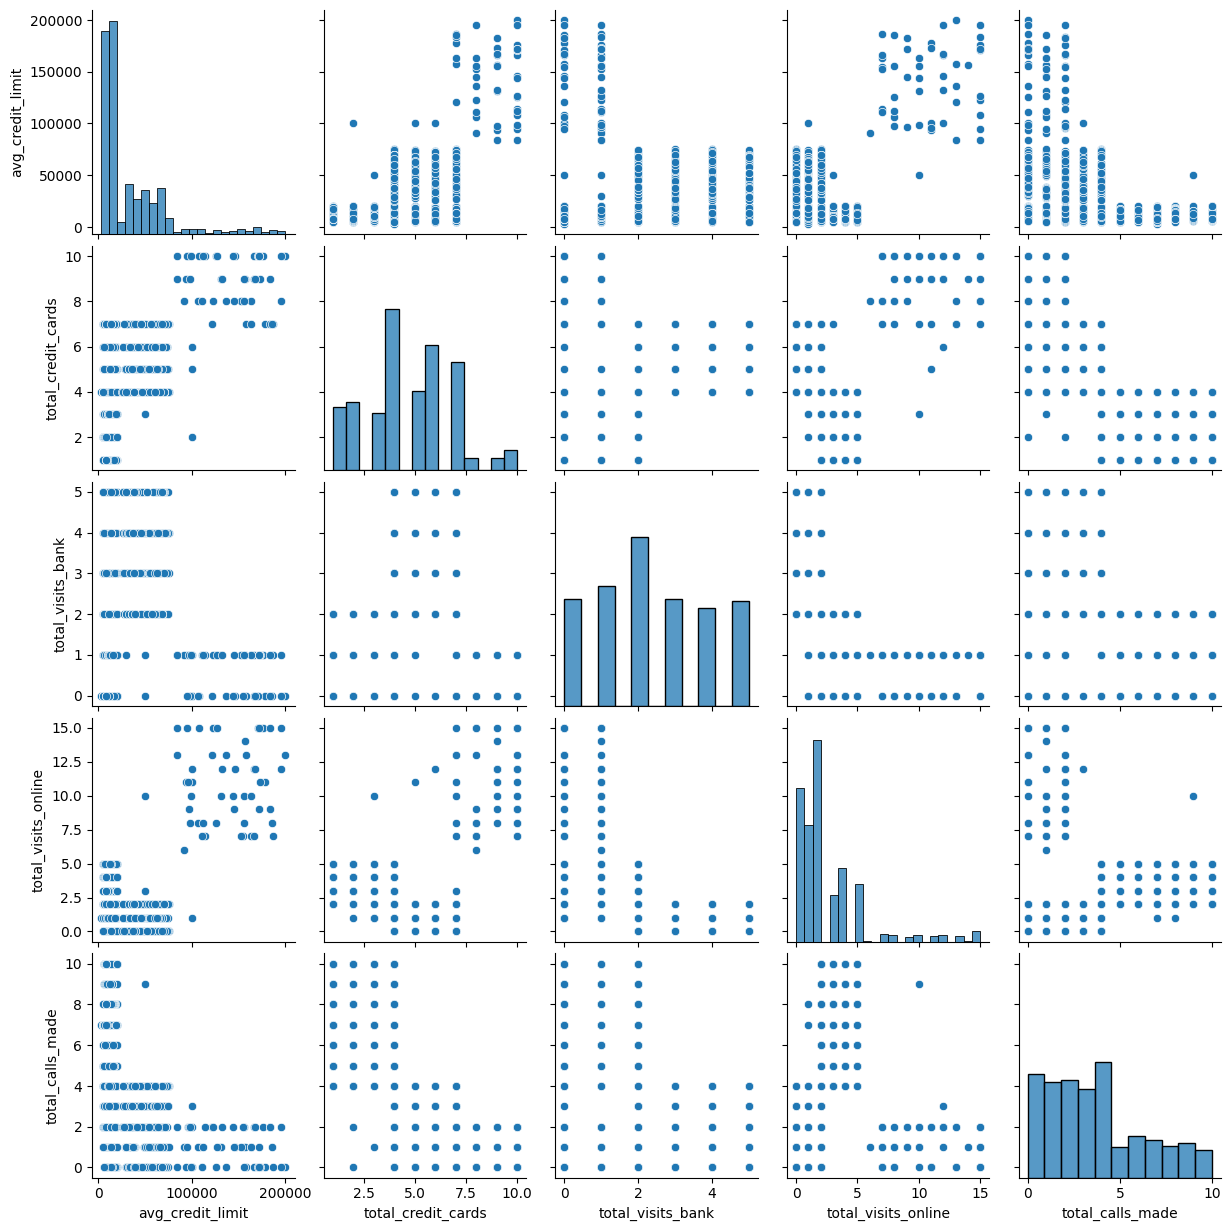

In [ ]:
# Pairwise relationship between different features
sns.pairplot(df)
plt.show()

### **Checking the Outlier** ###

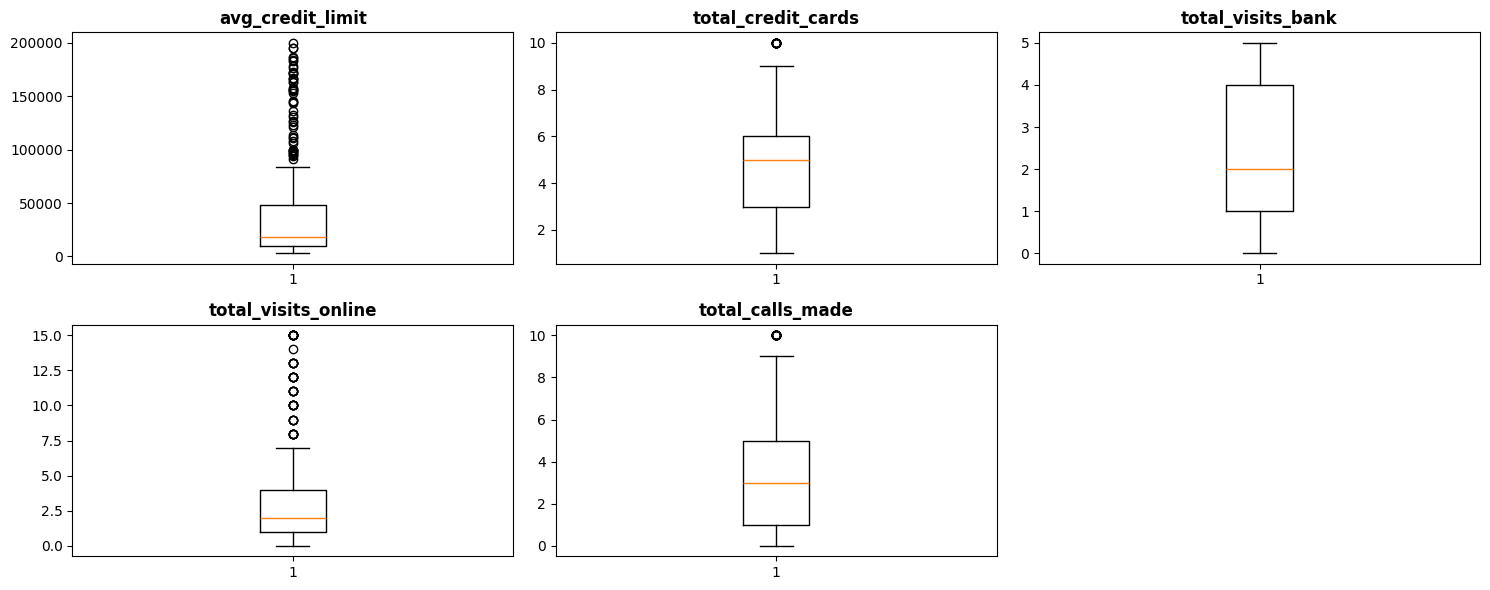

In [ ]:
#Plot using boxplot to check the outlier
plt.figure(figsize=(15,6))
for i,variable in enumerate(cols):
  plt.subplot(2,3,i+1)
  plt.boxplot(df[variable],whis=1)
  plt.title(variable, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation**
* The avg_credit_limit has many outliers. Since it will many valid information it better to retain the data.


#### **Scaling the data**

In [ ]:
#Apply the Z-Score to Standardize the data
from scipy.stats import zscore
zscore_Data=df[cols].apply(zscore)
zscore_Data.head()

,avg_credit_limit,total_credit_cards,total_visits_bank,total_visits_online,total_calls_made
0,1.740187,-1.249225,-0.860451,-0.547490,-1.251537
1,0.410293,-0.787585,-1.473731,2.520519,1.891859
2,0.410293,1.058973,-0.860451,0.134290,0.145528
3,-0.121665,0.135694,-0.860451,-0.547490,0.145528
4,1.740187,0.597334,-1.473731,3.202298,-0.203739


In [ ]:
# Apply the standard scaler

scaler=StandardScaler()
data_sk_std = df[cols].copy()
data_sk_std[cols]=scaler.fit_transform(data_sk_std[cols])
data_sk_std.head()

,avg_credit_limit,total_credit_cards,total_visits_bank,total_visits_online,total_calls_made
0,1.740187,-1.249225,-0.860451,-0.547490,-1.251537
1,0.410293,-0.787585,-1.473731,2.520519,1.891859
2,0.410293,1.058973,-0.860451,0.134290,0.145528
3,-0.121665,0.135694,-0.860451,-0.547490,0.145528
4,1.740187,0.597334,-1.473731,3.202298,-0.203739


#### **Applying PCA on scaled data**

In [ ]:
pca=PCA(n_components=2,random_state=42)
pca.fit_transform(data_sk_std)
data_pca_df=pd.DataFrame(pca.fit_transform(data_sk_std),columns=['PC1','PC2'])

print(f"\nPCA explained Variance :{pca.explained_variance_ratio_.round(4)}")
print(f"Total Explained Variance :{pca.explained_variance_ratio_.sum():.4f}")


PCA explained Variance :[0.4574 0.3743]
Total Explained Variance :0.8316


**Observation**
* Applied Principal Component Analysis with 2 components, capturing total variance of 83.16%(PC1 - 45.74%,PC2 - 37.43%), reducing the dimensionality while retaining the maximum information.

## **K-Means**

Let us now fit the K-means algorithm on our pca components and find out the optimum number of clusters to use.

We will do this in 3 steps:
1. Initialize a dictionary to store the Sum of Squared Error (SSE) for each K
2. Run for a range of Ks and store SSE for each run
3. Plot the SSE vs K and plot the elbow curve

**Create Clusters**
* n_clusters - int, default = 8. The number of clusters to form and the number of centroids to be generate.
* n_init - int, default=10. The number of time K-means algorithm will be run.
* max_tier - int, default=300. Maximum number of iterations of K-means in a single run.
* random_state - int, default = None. Random generated for centroid initialization.

In [ ]:
# Create and print the list the K-clusters

k_means_df=data_pca_df.copy()

cluster=range(1,20)
meanDistortions=[]
for k in cluster:
  model=KMeans(n_clusters=k,n_init=10,max_iter=300,random_state=42)
  model.fit(data_pca_df)
  prediction=model.predict(k_means_df)
  distortions=(sum(np.min(cdist(k_means_df,model.cluster_centers_,"euclidean"),axis=1))/ k_means_df.shape[0])
  meanDistortions.append(distortions)
  print("Number of Clusters:",k,"\tAverage Distortion:",distortions)


Number of Clusters: 1 	Average Distortion: 1.735529325469262
Number of Clusters: 2 	Average Distortion: 1.0532882751292973
Number of Clusters: 3 	Average Distortion: 0.676850674180707
Number of Clusters: 4 	Average Distortion: 0.5888554081453624
Number of Clusters: 5 	Average Distortion: 0.5353405958974988
Number of Clusters: 6 	Average Distortion: 0.48409905105435724
Number of Clusters: 7 	Average Distortion: 0.46139392712250177
Number of Clusters: 8 	Average Distortion: 0.4277188640319238
Number of Clusters: 9 	Average Distortion: 0.4043177269784676
Number of Clusters: 10 	Average Distortion: 0.383679397950248
Number of Clusters: 11 	Average Distortion: 0.3645229653652419
Number of Clusters: 12 	Average Distortion: 0.3425446372627016
Number of Clusters: 13 	Average Distortion: 0.32574165135196964
Number of Clusters: 14 	Average Distortion: 0.31985309559201136
Number of Clusters: 15 	Average Distortion: 0.3087863800488853
Number of Clusters: 16 	Average Distortion: 0.30379949693510777

**Finding the optimal of clusters number - K value**

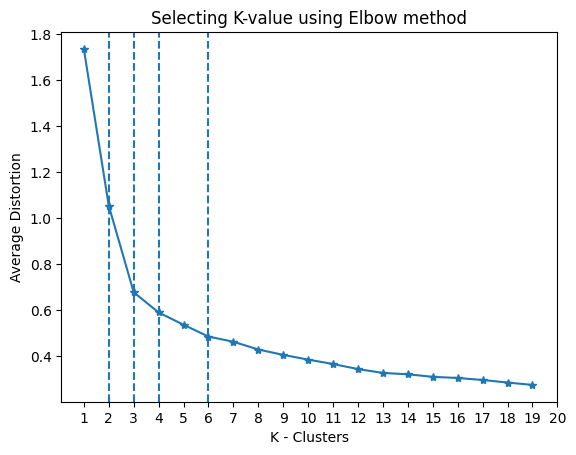

In [ ]:
#Plot the average distortion to identify the K value using elbow method
plt.plot(cluster,meanDistortions,marker="*")
plt.title("Selecting K-value using Elbow method")
plt.xlabel("K - Clusters")
plt.ylabel("Average Distortion")
plt.axvline(2, linestyle="--")
plt.axvline(3, linestyle="--")
plt.axvline(4, linestyle="--")
plt.axvline(6, linestyle="--")
plt.xticks(range(1,21,1))
plt.show()

**Interpret the above elbow plot and state the reason for choosing the particular value of K**
* From point 3, the graph starts to move parallel to the X-axis.
* This is an indication that K=3 is the optimal K-value for this cluster.


**Fit the K-means algorithms on the pca components with the number of clusters for the chosen value of K**

In [ ]:
# Fit K-Means on PCA components
kmeans = KMeans(n_clusters=3, random_state=1, n_init="auto")
kmeans.fit(k_means_df)


KMeans(n_clusters=3, random_state=1)

In [ ]:
#Creating a copy of the original data
df_cluster=newData.copy()

#Adding K-Means cluster labels to the K-Means and original dataframes
k_means_df['KMeans_Labels']=kmeans.labels_
df_cluster['KM_Segments']=kmeans.labels_


#### **Cluster Profiles by K-Means**  ####

In [ ]:
km_cluster_profiles=df_cluster.groupby('KM_Segments').mean(numeric_only=True)
print(km_cluster_profiles)

             customer_key  avg_credit_limit  total_credit_cards  \
KM_Segments                                                       
0            54881.329016      33782.383420            5.515544   
1            56708.760000     141040.000000            8.740000   
2            55239.830357      12174.107143            2.410714   

             total_visits_bank  total_visits_online  total_calls_made  
KM_Segments                                                            
0                     3.489637             0.981865          2.000000  
1                     0.600000            10.900000          1.080000  
2                     0.933036             3.553571          6.870536  


In [ ]:
# Creating the "count in each segment" feature in K-Means cluster profile
km_cluster_profiles["count_in_each_segment"]=(
    df_cluster.groupby("KM_Segments")["customer_key"].count().values
    )

In [ ]:
km_cluster_profiles.style.highlight_max(color='lightgreen')

,customer_key,avg_credit_limit,total_credit_cards,total_visits_bank,total_visits_online,total_calls_made,count_in_each_segment
KM_Segments,,,,,,,
0,54881.329016,33782.383420,5.515544,3.489637,0.981865,2.000000,386
1,56708.760000,141040.000000,8.740000,0.600000,10.900000,1.080000,50
2,55239.830357,12174.107143,2.410714,0.933036,3.553571,6.870536,224


In [ ]:
# Print customer_key in the each cluster
for cust in df_cluster['KM_Segments'].unique():
  print(f"Customer in Cluster {cust}")
  print(df_cluster[df_cluster['KM_Segments']==cust]['customer_key'].values)

Customer in Cluster 0
[87073 17341 40496 54838 35254 46635 97825 83125 35483 15129 83290 56486
 31903 45909 14263 46813 81878 35549 85799 39122 81531 69965 18595 44398
 32352 40898 27101 33457 45088 23302 27408 65372 21531 56843 17165 89328
 20072 71402 47496 24808 17036 67193 34423 97109 55382 51811 53936 66504
 53207 18514 51319 36340 36934 95925 49771 22919 21233 74544 52025 45652
 73952 49418 77026 49331 75775 54906 94666 11698 34677 95610 41380 38033
 85337 38994 67911 92956 77641 57565 53814 30712 19785 31384 16374 50878
 78002 83459 91987 51552 24998 45673 11596 87485 28414 81863 33240 11466
 23881 44645 49844 92782 22824 26767 26678 50412 17933 34495 47437 22610
 41159 64672 62483 85614 96548 19137 69028 70779 38244 67046 64897 46223
 36628 17565 77381 11799 81940 66706 87838 94437 33790 44402 29886 66804
 47866 61996 15318 89635 71681 71862 96186 22348 36243 88807 82376 98126
 80347 17649 62807 92522 57459 44579 45476 61994 11398 24702 27824 45878
 72431 19215 23409 16418 8512

In [ ]:
features = df_cluster.iloc[:, 1:-1].columns.tolist()

**Create the cluster profiles using the summary statistics and box plots for each label**

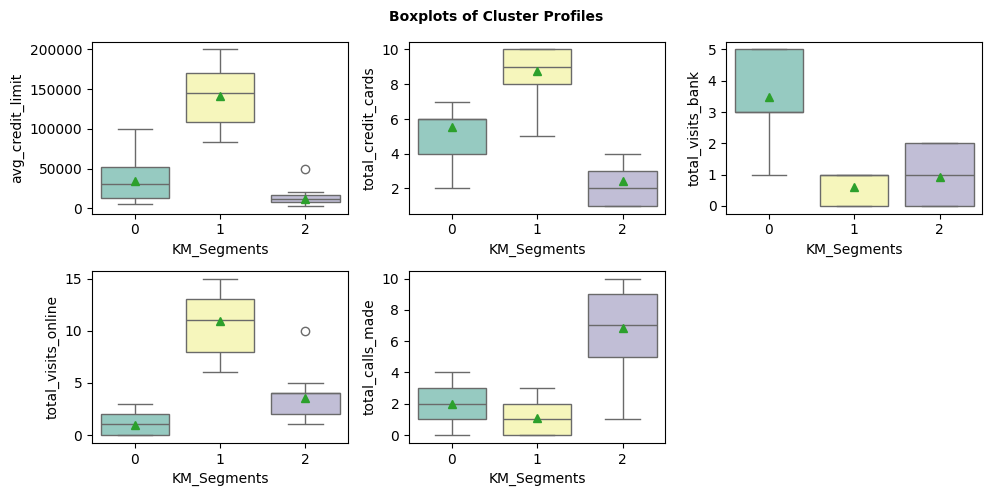

In [ ]:
# Plotting the cluster profiles using Boxplots

fig, axes = plt.subplots(2, 3,figsize=(10, 5))
fig.suptitle('Boxplots of Cluster Profiles', fontsize=10, fontweight='bold')
axes = axes.flatten()
counter=0

for i,col_name in enumerate(features):
  sns.boxplot(ax=axes[i],
        data=df_cluster,
        x="KM_Segments",
        y=col_name,
        showmeans=True,
        palette="Set3")
fig.delaxes(axes[-1])
fig.tight_layout(pad=1.0)
fig.show()

**Bar plot of customer segmentation based on K-Means**

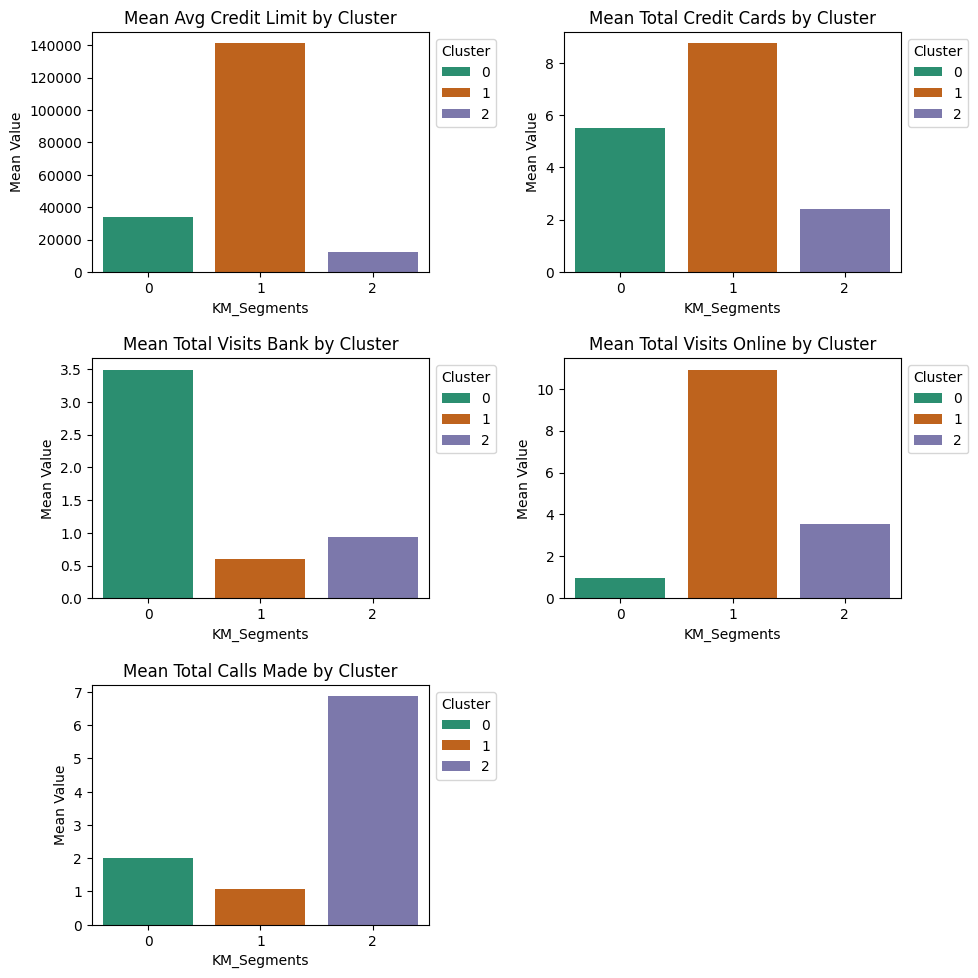

In [ ]:
# Set up a grid of subplots for your 5 numerical features
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.flatten()

for i, column in enumerate(features):
    # Clustered bar chart: x is the cluster, hue breaks it down by your other group
    sns.barplot(
        ax=axes[i],
        data=df_cluster,
        x="KM_Segments",
        y=column,
        hue="KM_Segments",  # Replace with your actual grouping column name
        errorbar=None,         # Removes error bars to keep the chart clean
        palette="Dark2"
    )

    axes[i].set_title(f"Mean {column.replace('_', ' ').title()} by Cluster")
    axes[i].set_ylabel("Mean Value")

    # Move the legend out of the way so it doesn't block the bars
    axes[i].legend(title="Cluster", bbox_to_anchor=(1, 1), loc='upper left')

# Clean up the empty 6th subplot
if len(axes) > len(features):
    fig.delaxes(axes[-1])

fig.tight_layout(pad=1.5)
plt.show()

**Observation**  

**Cluster 0 -  Mid-Tier Mainstream Customers**

* The customers with medium credit card limit of $33,382 belong to this cluster.
* These are typical mid income customers with a balanced mix of bank visit, online activity and low call frequency.
* They represent the core retail base and ideal candidate for upsell for premium products.

**Cluster 1 - Low Tier/Call-center dependent Customers**
* The customers with very low credit limit of $12174 belongs to the group.
* These customers contribute to the very high call center dependency.
* They frequently need support and have minimal online engagement.
* They will benefit from guided digital onboarding and proactive support.

**Cluster 2 - Premium High Value Customers**

* The customers with a high credit card limit of $141000 belong to this cluster.
* They hold the maximum number of credit cards in the dataset.
* They prefer digital channels(online visit) with low call frequency.
* This suggest financial literacy of the group is high.
* Targeted premium offers and loyalty programs would resonate best for this group

## **Gaussian Mixture Model**

Let's now create clusters using the Gaussian Mixture Model.

- Apply the Gaussian Mixture Model algorithm on the pca components

In [ ]:
# Fit Gaussian Model on PCA components
gmm_df=data_pca_df.copy()

gmm = GaussianMixture(n_components=3, random_state=1)
gmm.fit(data_pca_df)

#Copying the labels
gmm.labels=gmm.predict(data_pca_df)

In [ ]:
#Adding GMM cluster labels to the GMM and original dataframes
gmm_df['GMM_Labels']=gmm.labels
df_cluster['GMM_Segments']=gmm.labels


#### **Cluster Profiles by Gaussian Mixture Model** ####


In [ ]:
gmm_cluster_profiles=df_cluster.groupby('GMM_Segments').mean(numeric_only=True)
print(gmm_cluster_profiles)

              customer_key  avg_credit_limit  total_credit_cards  \
GMM_Segments                                                       
0             54881.329016      33782.383420            5.515544   
1             56708.760000     141040.000000            8.740000   
2             55239.830357      12174.107143            2.410714   

              total_visits_bank  total_visits_online  total_calls_made  \
GMM_Segments                                                             
0                      3.489637             0.981865          2.000000   
1                      0.600000            10.900000          1.080000   
2                      0.933036             3.553571          6.870536   

              KM_Segments  
GMM_Segments               
0                     0.0  
1                     1.0  
2                     2.0  


In [ ]:
# Creating the "count in each segment" feature in Gaussian Mixture Model cluster profile
gmm_cluster_profiles["count_in_each_segment"]=(
    df_cluster.groupby("GMM_Segments")["customer_key"].count().values
    )

In [ ]:
gmm_cluster_profiles.style.highlight_max(color='lightgreen')

,customer_key,avg_credit_limit,total_credit_cards,total_visits_bank,total_visits_online,total_calls_made,KM_Segments,count_in_each_segment
GMM_Segments,,,,,,,,
0,54881.329016,33782.383420,5.515544,3.489637,0.981865,2.000000,0.000000,386
1,56708.760000,141040.000000,8.740000,0.600000,10.900000,1.080000,1.000000,50
2,55239.830357,12174.107143,2.410714,0.933036,3.553571,6.870536,2.000000,224


In [ ]:
# Print customer_key in the each cluster
for cust in df_cluster['GMM_Segments'].unique():
  print(f"Customer in Cluster {cust}")
  print(df_cluster[df_cluster['GMM_Segments']==cust]['customer_key'].values)

Customer in Cluster 0
[87073 17341 40496 54838 35254 46635 97825 83125 35483 15129 83290 56486
 31903 45909 14263 46813 81878 35549 85799 39122 81531 69965 18595 44398
 32352 40898 27101 33457 45088 23302 27408 65372 21531 56843 17165 89328
 20072 71402 47496 24808 17036 67193 34423 97109 55382 51811 53936 66504
 53207 18514 51319 36340 36934 95925 49771 22919 21233 74544 52025 45652
 73952 49418 77026 49331 75775 54906 94666 11698 34677 95610 41380 38033
 85337 38994 67911 92956 77641 57565 53814 30712 19785 31384 16374 50878
 78002 83459 91987 51552 24998 45673 11596 87485 28414 81863 33240 11466
 23881 44645 49844 92782 22824 26767 26678 50412 17933 34495 47437 22610
 41159 64672 62483 85614 96548 19137 69028 70779 38244 67046 64897 46223
 36628 17565 77381 11799 81940 66706 87838 94437 33790 44402 29886 66804
 47866 61996 15318 89635 71681 71862 96186 22348 36243 88807 82376 98126
 80347 17649 62807 92522 57459 44579 45476 61994 11398 24702 27824 45878
 72431 19215 23409 16418 8512

#### **Create the cluster profiles using the summary statistics and box plots for each label**


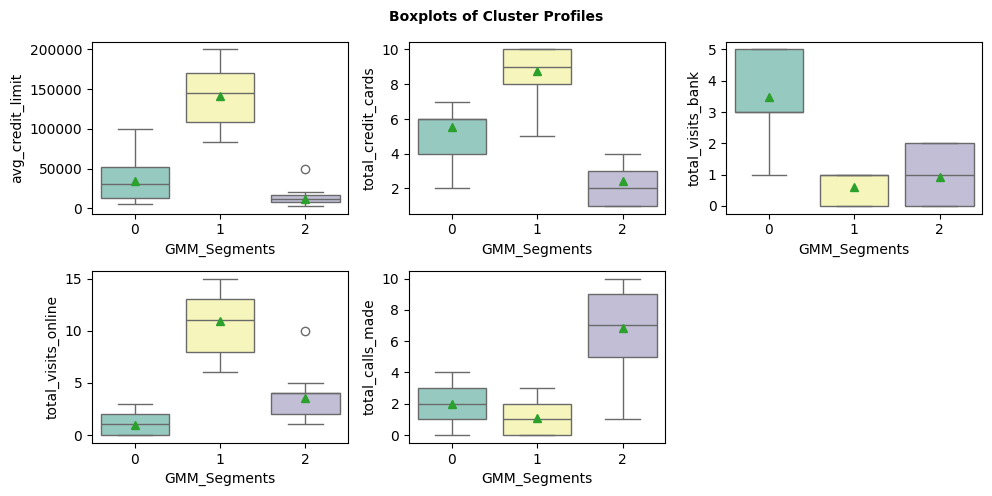

In [ ]:
# # Plotting the cluster profiles using Boxplots
fig, axes = plt.subplots(2, 3,figsize=(10, 5))
fig.suptitle('Boxplots of Cluster Profiles', fontsize=10, fontweight='bold')
axes = axes.flatten()
counter=0

for i,col_name in enumerate(features):
  sns.boxplot(ax=axes[i],
        data=df_cluster,
        x="GMM_Segments",
        y=col_name,
        showmeans=True,
        palette="Set3")
fig.delaxes(axes[-1])
fig.tight_layout(pad=1.0)
fig.show()

**Bar plot of customer segmentation based on Gaussian Mixture Model**


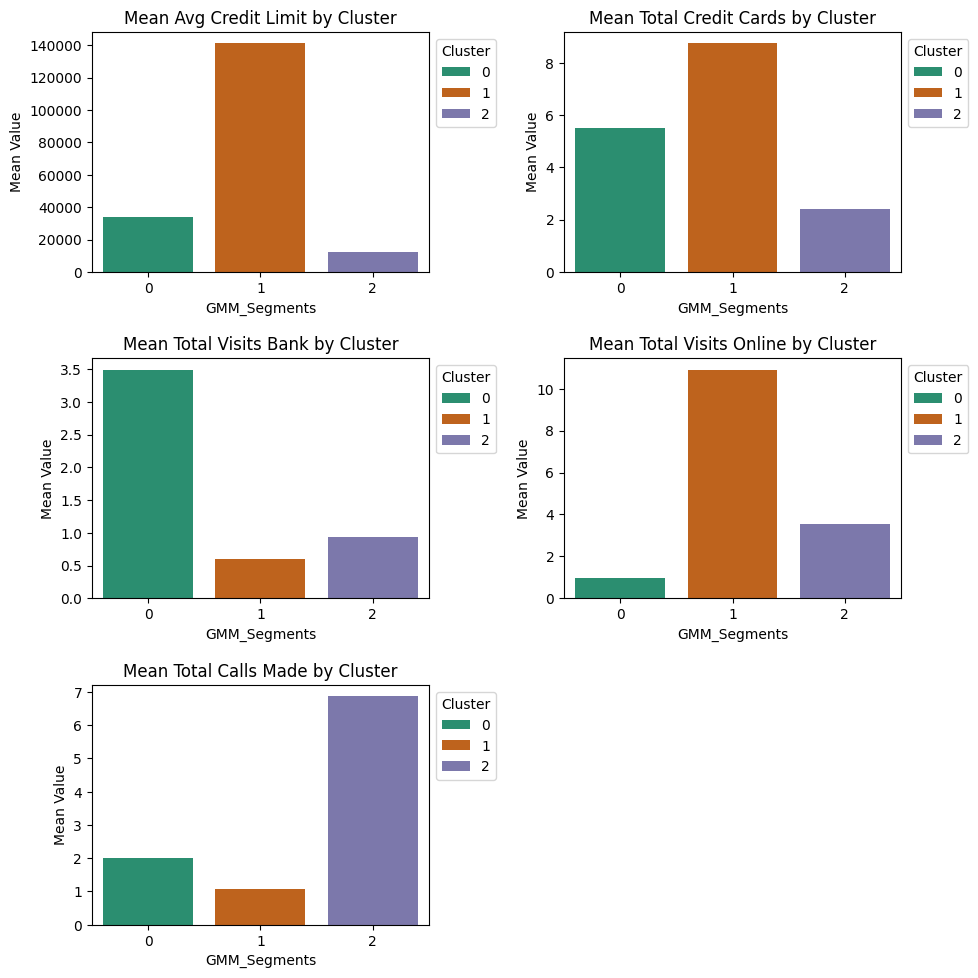

In [ ]:
# Set up a grid of subplots for your 5 numerical features
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.flatten()

for i, column in enumerate(features):
    # Clustered bar chart: x is the cluster, hue breaks it down by your other group
    sns.barplot(
        ax=axes[i],
        data=df_cluster,
        x="GMM_Segments",
        y=column,
        hue="GMM_Segments",  # Replace with your actual grouping column name
        errorbar=None,         # Removes error bars to keep the chart clean
        palette="Dark2"
    )

    axes[i].set_title(f"Mean {column.replace('_', ' ').title()} by Cluster")
    axes[i].set_ylabel("Mean Value")

    # Move the legend out of the way so it doesn't block the bars
    axes[i].legend(title="Cluster", bbox_to_anchor=(1, 1), loc='upper left')

# Clean up the empty 6th subplot
if len(axes) > len(features):
    fig.delaxes(axes[-1])

fig.tight_layout(pad=1.5)
plt.show()

**Observation**


**Cluster 0 - Mid-Tier Mainstream Customers**

* The largest customer base but with moderate credit limit($33,000).
* They use digital channels and visit banks equally.
* They are bank's core retail space.

**Cluster 1 - Low Tier Call center dependent Customers**

* Customers with low credit limit($12000).
* They have less financial literacy with high dependency on calls and bank visits.
* They have the lowest number of credit cards.
* Campaigns focusing on the financial literacy will highly engage them.

**Cluster 2 - Premium value Customers**

* Smallest group of customer with a high credit limit($140000).
* They prefer digital channels and less bank visits with high financial literacy.
* They warrant for VIP treatment, exclusive rewards and concerige treatment.


#### **Compare the clusters from both algorithms - K-means and Gaussian Mixture Model**




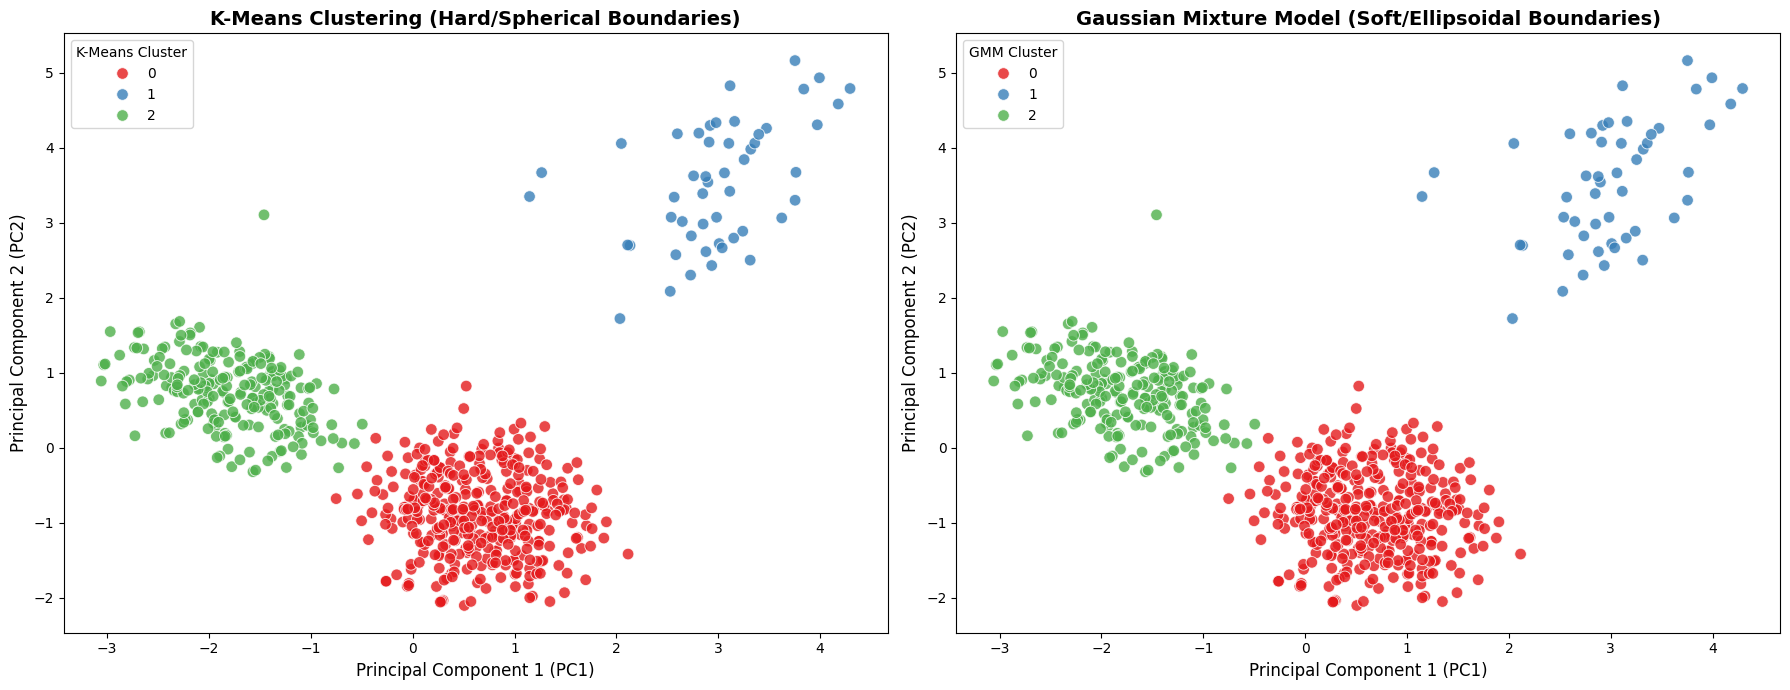

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a copy of your PCA data and bring in the cluster segments for plotting
plot_df = data_pca_df.copy()
plot_df['KM_Segments'] = df_cluster['KM_Segments']
plot_df['GMM_Segments'] = df_cluster['GMM_Segments']

# 2. Extract the exact string names of your first two PCA columns dynamically
pc1_name = data_pca_df.columns[0]  # Fixed: changed .column to .columns
pc2_name = data_pca_df.columns[1]  # Fixed: changed .column to .columns

# Set up a side-by-side plotting area
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Plotting K-Means Clustering
sns.scatterplot(
    x=pc1_name,
    y=pc2_name,
    hue='KM_Segments',
    data=plot_df,  # Updated: using the dataframe that contains the segments
    palette='Set1',
    alpha=0.8,
    ax=axes[0],
    s=70
)
axes[0].set_title('K-Means Clustering (Hard/Spherical Boundaries)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Principal Component 1 (PC1)', fontsize=12)
axes[0].set_ylabel('Principal Component 2 (PC2)', fontsize=12)
axes[0].legend(title='K-Means Cluster')

# 2. Plotting Gaussian Mixture Model Clustering
sns.scatterplot(
    x=pc1_name,
    y=pc2_name,
    hue='GMM_Segments',
    data=plot_df,  # Updated: using the dataframe that contains the segments
    palette='Set1',
    alpha=0.8,
    ax=axes[1],
    s=70
)
axes[1].set_title('Gaussian Mixture Model (Soft/Ellipsoidal Boundaries)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Principal Component 1 (PC1)', fontsize=12)
axes[1].set_ylabel('Principal Component 2 (PC2)', fontsize=12)
axes[1].legend(title='GMM Cluster')

plt.tight_layout()
plt.show()

In [ ]:
# Cross-tab comparison
print("=== Cross-Tabulation Matrix: K-Means vs Gaussian Mixture ===")
display(pd.crosstab(df_cluster['KM_Segments'], df_cluster['GMM_Segments']))

=== Cross-Tabulation Matrix: K-Means vs Gaussian Mixture ===


GMM_Segments,0,1,2
KM_Segments,,,
0,386,0,0
1,0,50,0
2,0,0,224


**Observation - Comparing K-Means and Gaussian Mixture Model**
* The cross tabulation shows a perfect one to one mapping between K-Means and GMM labels
* There is zero disaggreements between the labels.
* K-Means and GMM converged to the same partitioning. This shows the three clusters are well separated.

## **K-Medoids**



- Apply the K-Medoids clustering algorithm on the pca components

In [ ]:
# Initialize K-Medoids with 3 clusters
kmediods_df=data_pca_df.copy()

kmedoids = KMedoids(n_clusters=3, random_state=42, method='pam')
kmedoids.fit(data_pca_df)

# # Map labels back to the original dataframe for profile verification
# df['KMedoids_Labels'] = data_pca_df['KMedoids_Labels']

# # View the actual data points chosen as the final cluster centers (Medoids)
# print("=== Final Cluster Medoids (Actual Customer Indices) ===")
# print(kmedoids.medoid_indices_)

KMedoids(method='pam', n_clusters=3, random_state=42)

In [ ]:
#Adding KMediods cluster labels to the kmediods and original dataframes
kmediods_df['KMediods_Labels']=kmedoids.labels_
df_cluster['KMD_Segments']=kmedoids.labels_


#### **Cluster Profiles by K-Mediods Model** ####

In [ ]:
kmedoids_cluster_profiles=df_cluster.groupby('KMD_Segments').mean(numeric_only=True)
print(kmedoids_cluster_profiles)

              customer_key  avg_credit_limit  total_credit_cards  \
KMD_Segments                                                       
0             54925.966408      33713.178295            5.511628   
1             56708.760000     141040.000000            8.740000   
2             55163.973094      12197.309417            2.403587   

              total_visits_bank  total_visits_online  total_calls_made  \
KMD_Segments                                                             
0                      3.485788             0.984496          2.005168   
1                      0.600000            10.900000          1.080000   
2                      0.928251             3.560538          6.883408   

              KM_Segments  GMM_Segments  
KMD_Segments                             
0                0.005168      0.005168  
1                1.000000      1.000000  
2                2.000000      2.000000  


In [ ]:
# Creating the "count in each segment" feature in K-Mediods cluster profile
kmedoids_cluster_profiles["count_in_each_segment"]=(
    df_cluster.groupby("KMD_Segments")["customer_key"].count().values
    )

In [ ]:
kmedoids_cluster_profiles.style.highlight_max(color='lightgreen')

,customer_key,avg_credit_limit,total_credit_cards,total_visits_bank,total_visits_online,total_calls_made,KM_Segments,GMM_Segments,count_in_each_segment
KMD_Segments,,,,,,,,,
0,54925.966408,33713.178295,5.511628,3.485788,0.984496,2.005168,0.005168,0.005168,387
1,56708.760000,141040.000000,8.740000,0.600000,10.900000,1.080000,1.000000,1.000000,50
2,55163.973094,12197.309417,2.403587,0.928251,3.560538,6.883408,2.000000,2.000000,223


In [ ]:
# Print customer_key in the each cluster
for cust in df_cluster['KMD_Segments'].unique():
  print(f"Customer in Cluster {cust}")
  print(df_cluster[df_cluster['KMD_Segments']==cust]['customer_key'].values)

Customer in Cluster 0
[87073 17341 40496 54838 35254 46635 97825 83125 35483 15129 83290 56486
 31903 45909 14263 46813 81878 35549 85799 39122 81531 69965 18595 44398
 32352 40898 27101 33457 45088 23302 27408 65372 21531 56843 17165 89328
 20072 71402 47496 24808 17036 67193 34423 97109 55382 51811 53936 66504
 53207 18514 51319 36340 36934 95925 49771 22919 21233 74544 52025 45652
 73952 49418 77026 49331 75775 54906 94666 11698 34677 95610 41380 38033
 85337 38994 67911 92956 77641 57565 53814 30712 19785 31384 16374 50878
 78002 83459 91987 51552 72156 24998 45673 11596 87485 28414 81863 33240
 11466 23881 44645 49844 92782 22824 26767 26678 50412 17933 34495 47437
 22610 41159 64672 62483 85614 96548 19137 69028 70779 38244 67046 64897
 46223 36628 17565 77381 11799 81940 66706 87838 94437 33790 44402 29886
 66804 47866 61996 15318 89635 71681 71862 96186 22348 36243 88807 82376
 98126 80347 17649 62807 92522 57459 44579 45476 61994 11398 24702 27824
 45878 72431 19215 23409 1641

#### **Create cluster profiles using the summary statistics and box plots for each label**

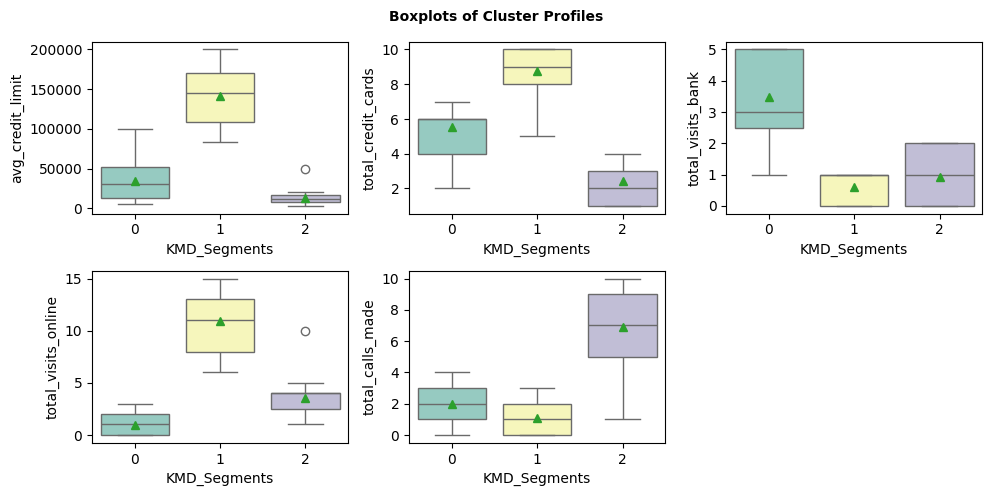

In [ ]:
# # Plotting the cluster profiles using Boxplots
fig, axes = plt.subplots(2, 3,figsize=(10, 5))
fig.suptitle('Boxplots of Cluster Profiles', fontsize=10, fontweight='bold')
axes = axes.flatten()
counter=0

for i,col_name in enumerate(features):
  sns.boxplot(ax=axes[i],
        data=df_cluster,
        x="KMD_Segments",
        y=col_name,
        showmeans=True,
        palette="Set3")
fig.delaxes(axes[-1])
fig.tight_layout(pad=1.0)
fig.show()

**Bar plot of customer segmentation based on K_Medoids**


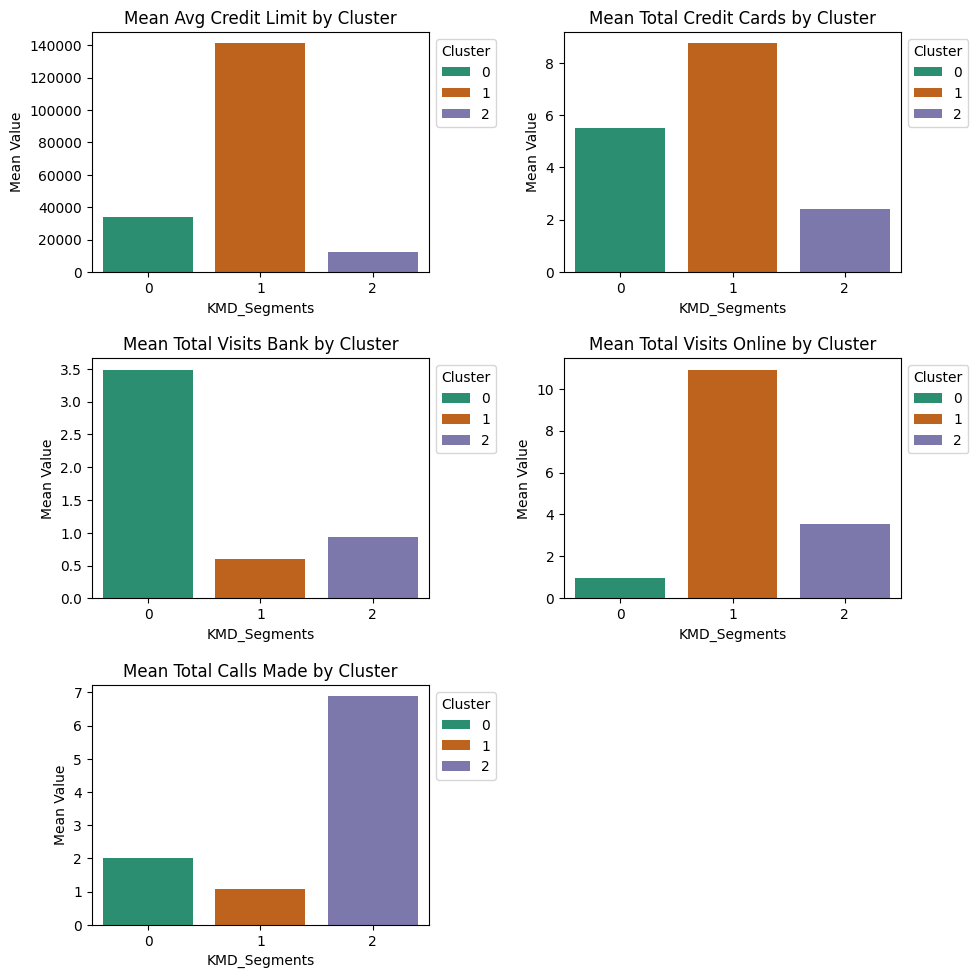

In [ ]:
# Set up a grid of subplots for your 5 numerical features
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.flatten()

for i, column in enumerate(features):
    # Clustered bar chart: x is the cluster, hue breaks it down by your other group
    sns.barplot(
        ax=axes[i],
        data=df_cluster,
        x="KMD_Segments",
        y=column,
        hue="KMD_Segments",  # Replace with your actual grouping column name
        errorbar=None,         # Removes error bars to keep the chart clean
        palette="Dark2"
    )

    axes[i].set_title(f"Mean {column.replace('_', ' ').title()} by Cluster")
    axes[i].set_ylabel("Mean Value")

    # Move the legend out of the way so it doesn't block the bars
    axes[i].legend(title="Cluster", bbox_to_anchor=(1, 1), loc='upper left')

# Clean up the empty 6th subplot
if len(axes) > len(features):
    fig.delaxes(axes[-1])

fig.tight_layout(pad=1.5)
plt.show()

**Observation**

**Cluster 0 - Mid tier mainStream customers**
* They are middle tier retail banking customer.
* They prefer visiting the bank with low online presence and zero call center experience

**Cluster 1 - Low Tier Call center dependent customers**
* They are call center dependent low engagement customers.
* Their financial literacy is very low.

**Cluster 2 - Premium value customers** *italicized text*
* They are high value digital friendly customers.
* They have the highest number of credit cards with 0 visit to the bank


#### **Compare the clusters from K-Means and K-Medoids**

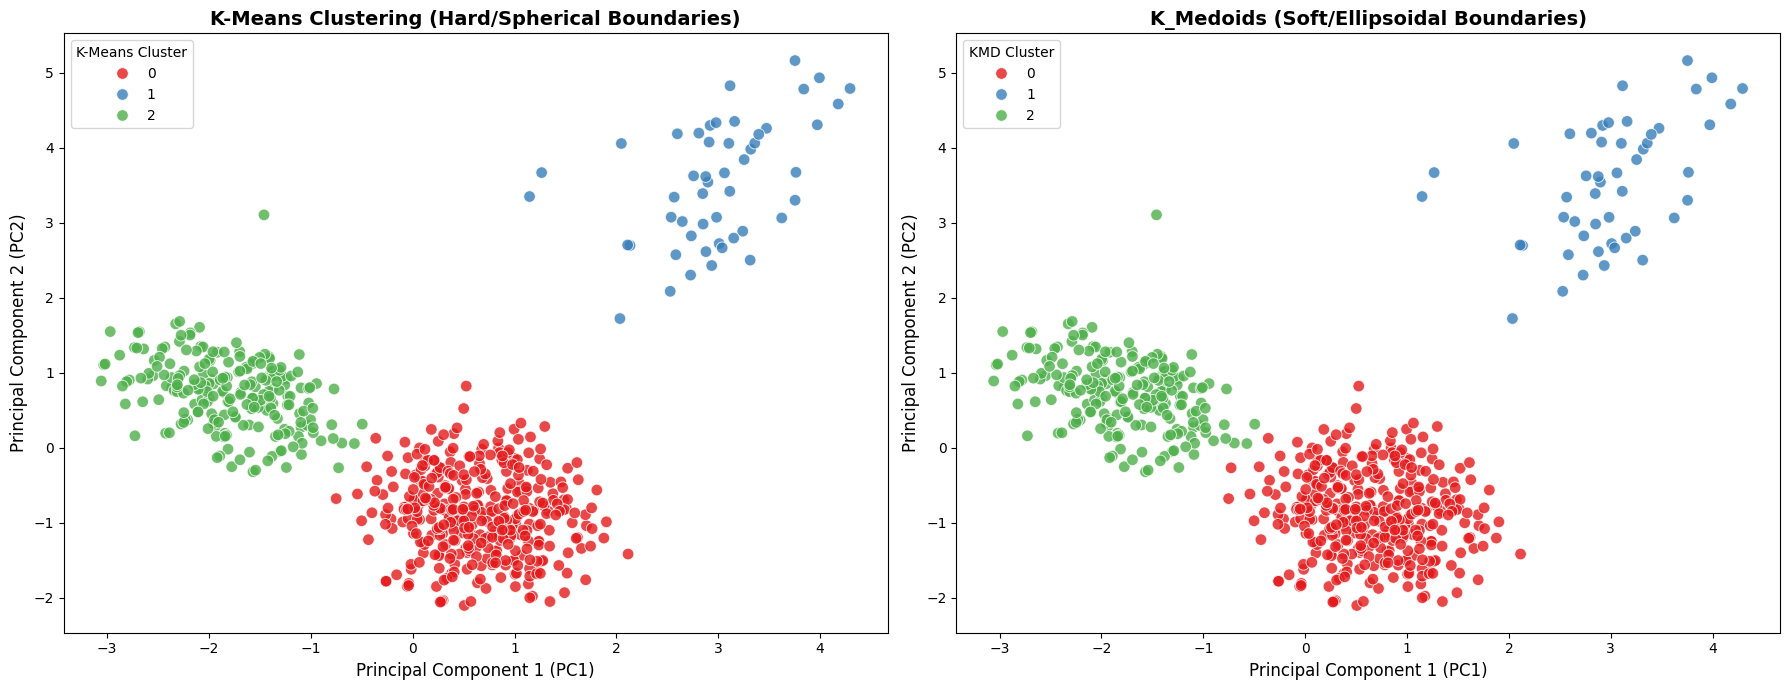

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a copy of your PCA data and bring in the cluster segments for plotting
plot_df = data_pca_df.copy()
plot_df['KM_Segments'] = df_cluster['KM_Segments']
plot_df['KMD_Segments'] = df_cluster['KMD_Segments']

# 2. Extract the exact string names of your first two PCA columns dynamically
pc1_name = data_pca_df.columns[0]  # Fixed: changed .column to .columns
pc2_name = data_pca_df.columns[1]  # Fixed: changed .column to .columns

# Set up a side-by-side plotting area
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Plotting K-Means Clustering
sns.scatterplot(
    x=pc1_name,
    y=pc2_name,
    hue='KM_Segments',
    data=plot_df,  # Updated: using the dataframe that contains the segments
    palette='Set1',
    alpha=0.8,
    ax=axes[0],
    s=70
)
axes[0].set_title('K-Means Clustering (Hard/Spherical Boundaries)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Principal Component 1 (PC1)', fontsize=12)
axes[0].set_ylabel('Principal Component 2 (PC2)', fontsize=12)
axes[0].legend(title='K-Means Cluster')

# 2. Plotting K_Medoids Model Clustering
sns.scatterplot(
    x=pc1_name,
    y=pc2_name,
    hue='KMD_Segments',
    data=plot_df,  # Updated: using the dataframe that contains the segments
    palette='Set1',
    alpha=0.8,
    ax=axes[1],
    s=70
)
axes[1].set_title('K_Medoids (Soft/Ellipsoidal Boundaries)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Principal Component 1 (PC1)', fontsize=12)
axes[1].set_ylabel('Principal Component 2 (PC2)', fontsize=12)
axes[1].legend(title='KMD Cluster')

plt.tight_layout()
plt.show()

In [ ]:
# Cross-tab comparison
print("=== Cross-Tabulation Matrix: K-Means vs K-Medoids ===")
display(pd.crosstab(df_cluster['KM_Segments'], df_cluster['KMD_Segments']))

=== Cross-Tabulation Matrix: K-Means vs K-Medoids ===


KMD_Segments,0,1,2
KM_Segments,,,
0,386,0,0
1,0,50,0
2,1,0,223


**Comparing Clusters:**
* K-Medoids found essentially the same three group like K-Means but numbered two of them differently.
* There was one data points that was assigned differently. But the clusteres were well separated and stable
* K-Means and K_Medoids almost matching clusters.

## **Conclusions and Business Recommendations**

**Key Findings**
* Three distinct customer segments were identified.
* K-Means and Gaussian Model produced identical clusters.
* K-Medoids produced a partially different clusters.
* PCA reduction to 2 components retained 83% variance indicating the 5 features retain a substantial information.

**For the marketing team**
* Cluster 2 - Premium Customers : Launch exclusive loyalty and rewards programs. Offer premium credit cards and concierge services. Promote campaigns of the products through digital channel as they are heavily digital friendly
* Cluster 1 - Support Budget Customers : Introduce low fee products with free financial literacy programs for better engagement. Convert these customers to digital friendly to reduce the load in the call center.
* Cluster 0 - Mid Tier : Introduce upsell campaigns for travel cards, credit limit upgrades, cash back programs to increase the engagement. Encourage customers to adopt digital channels for transactions.

**For the Operations Team**
* Prioritizing the call from cluster 1(budget support) will reduce the operational cost because of their heavy relabilty on call center.
* Ensure there is dedicated high priority lines for the cluster 2 (premium customer)
* Develop proactive digital campaigns and query programs to help the cluster 1( support budget)
* Develop AI chatbots to answer and self guided portals to help cluster 1 customers(support budget) to reduce the high call volume.
